In [1]:
!pip install -U pip
!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -U transformers datasets accelerate peft trl bitsandbytes huggingface_hub
!pip install -U unsloth
!pip install -U wandb
!pip install -U langchain langchain-community langgraph faiss-cpu sentence-transformers
!pip install -U tqdm
!pip install -q fastapi uvicorn pyngrok nest-asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 22.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 12.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 18.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 22.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 55.2 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 61.5 MB/s  0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.7.1
    U

In [ ]:
import torch
import gc
torch.cuda.empty_cache()
gc.collect()

30

In [2]:
import os
import re
import gc
import math
import torch
import threading
import numpy as np
import pandas as pd

from tqdm import tqdm
from datetime import datetime
from typing import TypedDict, Annotated, List, Dict

from huggingface_hub import login
from unsloth import FastLanguageModel
from transformers import StoppingCriteria, StoppingCriteriaList
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END
from sentence_transformers import SentenceTransformer, util

import nest_asyncio
import uvicorn
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from pyngrok import ngrok

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
Base_Model = "meta-llama/Llama-3.1-8B-Instruct"
PROJECT_NAME = "Topper"
HF_USER = "Shivam2407"
Dataset_Name1 = "whiteOUO/Ladder-machine-learning-QA"
Dataset_Name2 = "Mridul-Dixit/Machine-Learning-QA-Dataset"
PROJECT_RUN_NAME = f"{PROJECT_NAME}"
HUB_MODEL_NAME = f"{HF_USER}/{PROJECT_RUN_NAME}"
LORA_R = 16
LORA_ALPHA = 32
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",]
LORA_DROPOUT = 0.1
QUANT_CONFIG = True
EPOCHS = 1
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 1
LEARNING_RATE = 1e-4
LR_SCHEDULER_TYPE = 'cosine'
WARMUP_RATIO = 0.03
OPTIMIZER = "paged_adamw_8bit"
STEPS = 50
SAVE_STEPS = 2000
LOG_TO_WANDB = True

In [4]:
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
login(hf_token)

In [5]:
def get_marks(question: str) -> int:
    """Extract marks value from question string e.g. 'Marks: 6' -> 6"""
    m = re.search(r"Marks\s*:\s*(\d+)", question)
    return int(m.group(1)) if m else 5


def tokens_from_marks(marks: int):
    if marks <= 2:   return 120, 60
    elif marks <= 4: return 220, 120
    elif marks <= 6: return 320, 180
    elif marks <= 8: return 450, 250
    else:            return 550, 300


def clean_answer(text: str) -> str:
    """
    Strip all 'Marks' artifacts the model sometimes appends.
    Called before every answer is returned to the frontend.
    """
    text = re.sub(r'(?im)^\s*Marks\s*(:\s*\d+|\s+\w+)?\s*$', '', text)  # whole-line Marks
    text = re.sub(r'Marks\s*:\s*\d+', '', text)                          # inline Marks: N
    text = re.sub(r'\bMarks\b\s*', '', text)                              # bare word Marks
    text = re.sub(r'\n{3,}', '\n\n', text)                               # collapse blank lines
    return text.strip()


print("Helper functions defined.")

Helper functions defined.


In [6]:
from datasets import load_dataset
dataset3_path = "/content/improved_q_a.json"
dataset1 = load_dataset(Dataset_Name1)
train_data1 = dataset1['train']
dataset2 = load_dataset(Dataset_Name2)
train_data2 = dataset2['train']
dataset3 = load_dataset("json",data_files=dataset3_path,split="train")


documents = []
for row in train_data1:
    text = f"Question: {row['Question']} Answer : {row['Answer']}"
    documents.append(
        Document(page_content=text)
    )
for row in train_data2:
    text = f"Question: {row['question']} Answer : {row['answer']}"
    documents.append(
        Document(page_content=text)
    )
for row in dataset3:
    question = ""
    answer = ""
    for message in row["messages"]:
        if message["role"] == "user":
            question = message["content"]
        elif message["role"] == "assistant":
            answer = message["content"]

    text = f"Question: {question}\nAnswer: {answer}"
    documents.append(Document(page_content=text))
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=40,
    separators=["\n\n", "\n", ".", " ", ""]
)
documents = text_splitter.split_documents(documents)
print(f"Total chunks after splitting: {len(documents)}")

(…)achine_learning_convolution_layer_qa.csv: 0.00B [00:00, ?B/s]

machine_learning_keras.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/64 [00:00<?, ? examples/s]

ML-101-QandA.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/101 [00:00<?, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Total chunks after splitting: 1356


In [7]:
embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)

/tmp/ipykernel_1776/308441585.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
vectorstore = FAISS.from_documents(documents,embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k":4})

In [ ]:
torch.cuda.empty_cache()
gc.collect()

432

In [9]:
from unsloth import FastLanguageModel

base_model = "unsloth/llama-3-8b-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=base_model,
    max_seq_length=2048,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0.01,
    bias="none",
    use_gradient_checkpointing=False,  # False for inference
)

from peft import set_peft_model_state_dict
from huggingface_hub import hf_hub_download
import torch

weights_path = hf_hub_download(
    repo_id="Shivam2407/llama-dl-ml-theory-lora-2",
    filename="adapter_model.safetensors"  # or adapter_model.bin
)

state_dict = torch.load(weights_path, map_location="cpu") \
    if weights_path.endswith(".bin") \
    else None

if weights_path.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_path)

set_peft_model_state_dict(model, state_dict)

FastLanguageModel.for_inference(model)

==((====))==  Unsloth 2026.3.10: Fast Llama patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/198 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3-8b-bnb-4bit as a legacy tokenizer.
Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.01.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.3.10 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


adapter_model.safetensors:   0%|          | 0.00/54.6M [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 4096, padding_idx=128255)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.01, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
       

In [10]:
class RAGState(TypedDict):
    question: str
    docs: List[documents]
    answer: str

In [11]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [12]:
def retrieve(state: RAGState):
    docs = retriever.invoke("Machine Learning theory: " + state["question"])
    return {"docs": docs}

In [13]:
tokenizer.chat_template = (
    "{% set loop_messages = messages %}"
    "{% for message in loop_messages %}"
    "{% if message['role'] == 'system' %}{{ '<|start_header_id|>system<|end_header_id|>\n\n' + message['content'] + '<|eot_id|>' }}"
    "{% elif message['role'] == 'user' %}{{ '<|start_header_id|>user<|end_header_id|>\n\n' + message['content'] + '<|eot_id|>' }}"
    "{% elif message['role'] == 'assistant' %}{{ '<|start_header_id|>assistant<|end_header_id|>\n\n' + message['content'] + '<|eot_id|>' }}"
    "{% endif %}{% endfor %}"
    "{% if add_generation_prompt %}{{ '<|start_header_id|>assistant<|end_header_id|>\n\n' }}{% endif %}"
)

In [14]:
from transformers import StoppingCriteria, StoppingCriteriaList
class StopOnMarks(StoppingCriteria):
    def __init__(self, tokenizer, input_length):
        self.tokenizer    = tokenizer
        self.input_length = input_length

    def __call__(self, input_ids, scores, **kwargs):
        new_tokens = input_ids[0][self.input_length:]
        text = self.tokenizer.decode(new_tokens, skip_special_tokens=True)
        return "Marks:" in text[-30:] or "Marks :" in text[-30:]

In [15]:
def generate(state: RAGState):
    marks   = get_marks(state["question"])          # ← now defined above, no crash
    context = "\n\n".join([d.page_content for d in state["docs"]])

    system_prompt = f"""You are an expert Machine Learning professor writing exam answers.

Rules:
- Write a complete, well-structured answer for a {marks}-mark question.
- Use clear headings if needed (e.g., Definition, Causes, Effects, Remedy).
- Be concise but thorough — match depth to marks.
- Do NOT write "Marks", "Marks:", or any mark notation in your answer.
- Do NOT repeat the question.
- Stop writing once the answer is complete. Do not add anything after.
- Answer only what is asked. Do not generate follow-up questions."""

    user_prompt = f"""Use the context below to answer the question.\n\nContext:\n{context}\n\nQuestion: {state['question']}\n\nWrite only the answer now:"""

    messages  = [{"role": "system", "content": system_prompt},
                 {"role": "user",   "content": user_prompt}]
    chat_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs    = tokenizer(chat_text, return_tensors="pt", truncation=True, max_length=2048).to(model.device)

    input_length = inputs["input_ids"].shape[-1]
    max_tokens, _ = tokens_from_marks(marks)

    outputs = model.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        max_new_tokens=max_tokens,
        temperature=0.2, top_p=0.85, do_sample=True,
        repetition_penalty=1.3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
        stopping_criteria=StoppingCriteriaList([StopOnMarks(tokenizer, input_length)]),
        use_cache=False,
    )

    raw = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)
    return {"answer": clean_answer(raw)}

In [16]:

graph = StateGraph(RAGState)
graph.add_node("retrieve", retrieve)
graph.add_node("generate",generate)
graph.set_entry_point("retrieve")

graph.add_edge("retrieve", "generate")
graph.add_edge("generate",END)
app = graph.compile()

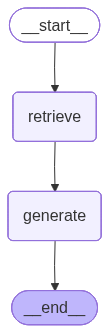

In [17]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
query = """What is underfitting in Machine Learning?
Marks: 5"""

output = app.invoke(
    {"question": query}
)

print(output["answer"])

Both `max_new_tokens` (=320) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Introduction
Machine learning models aim to learn patterns from data so that they can make accurate predictions. However, sometimes models fail to capture the true relationship between features and target variables.

Underfitting refers to a situation where a model is too simple and cannot effectively capture the underlying structure of the dataset.

Causes
Common causes include using too few parameters, insufficient training data or inappropriate model selection.

Effects
Underfitting leads to high training error, low prediction accuracy and poor generalization ability.

Solution
To address underfitting, models can be made more complex by increasing the number of parameters or adding additional layers in neural networks. Alternatively, data augmentation techniques may be used to improve dataset quality.

Marks Weighting
Introduction: 1 mark
Causes: 2 marks
Effects: 2 marks
Remedies: 3 marks
Marks Distribution: Introduction (1), Causes (2), Effects (2), Remedies (3)
Total Marks: 8
Mark

In [18]:
import re
from transformers import StoppingCriteria, StoppingCriteriaList

def get_marks(question: str) -> int:
    """Extract marks from question string e.g. 'Marks: 6' -> 6"""
    m = re.search(r"Marks\s*:\s*(\d+)", question)
    if m:
        return int(m.group(1))
    return 5  # default if not specified

def tokens_from_marks(marks: int):
    if marks <= 2:
        return 120, 60
    elif marks <= 4:
        return 220, 120
    elif marks <= 6:
        return 320, 180
    elif marks <= 8:
        return 450, 250
    else:
        return 550, 300

print("get_marks and tokens_from_marks defined.")

get_marks and tokens_from_marks defined.


In [19]:
!pip install -q sentence-transformers

In [20]:
from sentence_transformers import SentenceTransformer, util
import torch
import re
import numpy as np

sbert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("SBERT model loaded successfully.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT model loaded successfully.


In [21]:
def get_llama_answer(question: str) -> str:
    """Get the reference answer from the Llama RAG pipeline."""
    output = app.invoke({"question": question})
    return clean_answer(output["answer"])  # clean before returning to frontend


def extract_keywords(text: str) -> set:
    """Extract meaningful keywords (nouns/terms) from text, ignoring stopwords."""
    stopwords = {
        "a", "an", "the", "is", "are", "was", "were", "be", "been", "being",
        "have", "has", "had", "do", "does", "did", "will", "would", "could",
        "should", "may", "might", "shall", "can", "to", "of", "in", "on",
        "at", "by", "for", "with", "about", "as", "into", "through", "and",
        "or", "but", "not", "it", "its", "this", "that", "these", "those",
        "they", "we", "you", "he", "she", "i", "me", "my", "our", "your",
        "which", "when", "where", "who", "how", "what", "also", "so", "if",
        "then", "both", "while", "such", "more", "less", "very", "from"
    }
    words = re.findall(r'\b[a-zA-Z][a-zA-Z0-9_-]{2,}\b', text.lower())
    return {w for w in words if w not in stopwords}


def compute_keyword_coverage(student_answer: str, reference_answer: str) -> float:
    """Compute what fraction of reference keywords appear in student answer."""
    ref_keywords = extract_keywords(reference_answer)
    stu_keywords = extract_keywords(student_answer)
    if not ref_keywords:
        return 1.0
    matched = ref_keywords & stu_keywords
    return len(matched) / len(ref_keywords)


def compute_semantic_similarity(student_answer: str, reference_answer: str) -> float:
    """Compute cosine similarity between SBERT embeddings of both answers."""
    embeddings = sbert_model.encode(
        [student_answer, reference_answer],
        convert_to_tensor=True
    )
    similarity = util.cos_sim(embeddings[0], embeddings[1]).item()
    return max(0.0, similarity)   # clamp negatives to 0


def evaluate_answer(
    question: str,
    student_answer: str,
    semantic_weight: float = 0.7,
    keyword_weight: float = 0.3,
    verbose: bool = True
) -> dict:
    """
    Full evaluation pipeline:
      1. Get Llama reference answer for the question.
      2. Compute SBERT semantic similarity.
      3. Compute keyword coverage.
      4. Compute weighted final score.
      5. Assign grade label.

    Returns a dict with all scores and the reference answer.
    """
    marks = get_marks(question)

    print(f"Generating Llama reference answer for {marks}-mark question...")
    reference_answer = get_llama_answer(question)

    sem_score  = compute_semantic_similarity(student_answer, reference_answer)
    kw_score   = compute_keyword_coverage(student_answer, reference_answer)
    final_score = (semantic_weight * sem_score) + (keyword_weight * kw_score)

    # Map score → grade label
    if final_score >= 0.80:
        grade = "Excellent"
    elif final_score >= 0.65:
        grade = "Good"
    elif final_score >= 0.50:
        grade = "Average"
    elif final_score >= 0.35:
        grade = "Below Average"
    else:
        grade = "Poor"

    # Estimated marks awarded (scaled to question marks)
    awarded_marks = round(final_score * marks, 1)

    result = {
        "question":           question,
        "marks":              marks,
        "semantic_similarity": round(sem_score,  4),
        "keyword_coverage":   round(kw_score,   4),
        "final_score":        round(final_score, 4),
        "grade":              grade,
        "awarded_marks":      awarded_marks,
        "reference_answer":   reference_answer,
        "student_answer":     student_answer,
    }

    if verbose:
        print("\n" + "="*60)
        print("  EVALUATION REPORT")
        print("="*60)
        print(f"  Question Marks     : {marks}")
        print(f"  Semantic Similarity: {sem_score:.2%}  (weight={semantic_weight})")
        print(f"  Keyword Coverage   : {kw_score:.2%}  (weight={keyword_weight})")
        print(f"  Final Score        : {final_score:.2%}")
        print(f"  Grade              : {grade}")
        print(f"  Awarded Marks      : {awarded_marks} / {marks}")
        print("="*60)
        print("\n--- REFERENCE ANSWER (Llama) ---")
        print(reference_answer)
        print("\n--- STUDENT ANSWER ---")
        print(student_answer)
        print("="*60)

    return result

print("Evaluation functions defined successfully.")

Evaluation functions defined successfully.


In [ ]:
# ── INPUT: Edit these two values ──────────────────────────────────────────────

QUESTION = """What is the difference between underfitting and overfitting in Machine Learning?
Marks: 8"""

STUDENT_ANSWER = """
Overfitting happens when a model learns the training data too well, including noise.
It performs great on training data but poorly on new data.
Underfitting happens when the model is too simple to capture the pattern in data.
Both training and test errors remain high in underfitting.
"""

# ── Run evaluation ─────────────────────────────────────────────────────────────
result = evaluate_answer(
    question=QUESTION,
    student_answer=STUDENT_ANSWER,
    semantic_weight=0.7,   # 70% weight on semantic meaning
    keyword_weight=0.3     # 30% weight on keyword coverage
)

In [22]:
import re
import nest_asyncio
import uvicorn
import threading
import uuid
from datetime import datetime
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from pyngrok import ngrok
from typing import Dict, List, Optional

# ── In-memory store (survives while Colab session is alive) ──────────────────
# assignments: { assignment_id: { id, title, teacher_id, questions:[{text,marks}],
#                                  created_at, submissions:{student_id:{...}} } }
db_assignments: dict = {}

# ── Ngrok token from Colab secrets ────────────────────────────────────────────
ngrok.set_auth_token(userdata.get('NGROK'))

# ── FastAPI ───────────────────────────────────────────────────────────────────
fast_app = FastAPI(title="Llama ML Evaluator API  v2")

fast_app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# ─────────────────────────────────────────────────────────────────────────────
# Pydantic models
# ─────────────────────────────────────────────────────────────────────────────
class QuestionItem(BaseModel):
    text: str
    marks: int = 5              # ← each question carries its own marks value

class CreateAssignmentRequest(BaseModel):
    teacher_id: str
    title: str
    questions: List[QuestionItem]   # list of {text, marks}

class SubmitAssignmentRequest(BaseModel):
    student_id: str
    student_name: str
    answers: List[str]          # one answer string per question, same order

class EvaluateStudentRequest(BaseModel):
    student_id: str             # evaluate one student

class GenerateRequest(BaseModel):
    question: str
    marks: int = 5

class EvaluateRequest(BaseModel):
    question: str
    student_answer: str
    semantic_weight: float = 0.7
    keyword_weight: float = 0.3

class BatchEvaluateRequest(BaseModel):
    question: str
    answers: Dict[str, str]           # {submission_id: student_answer}
    reference_answer: Optional[str] = None   # pass pre-generated ref to skip Llama

# ─────────────────────────────────────────────────────────────────────────────
# Helper: evaluate one question-answer pair
# ─────────────────────────────────────────────────────────────────────────────
def _eval_one(question_text: str, marks: int, student_answer: str) -> dict:
    """Run Llama + SBERT evaluation for a single Q&A pair."""
    q = question_text
    if not re.search(r"Marks\s*:\s*\d+", q):
        q = f"{q}\nMarks: {marks}"
    reference = get_llama_answer(q)
    sem   = compute_semantic_similarity(student_answer, reference)
    kw    = compute_keyword_coverage(student_answer, reference)
    final = round(0.7 * sem + 0.3 * kw, 4)
    awarded = round(final * marks, 1)
    if   final >= 0.80: grade = "Excellent"
    elif final >= 0.65: grade = "Good"
    elif final >= 0.50: grade = "Average"
    elif final >= 0.35: grade = "Below Average"
    else:               grade = "Poor"
    return {
        "question":            question_text,
        "marks":               marks,
        "student_answer":      student_answer,
        "reference_answer":    reference,
        "semantic_similarity": round(sem, 4),
        "keyword_coverage":    round(kw, 4),
        "final_score":         final,
        "awarded_marks":       awarded,
        "grade":               grade,
    }

# ─────────────────────────────────────────────────────────────────────────────
# HEALTH
# ─────────────────────────────────────────────────────────────────────────────
@fast_app.get("/health")
def health():
    return {"status": "ok", "model": "llama-3-8b-lora-ml-theory",
            "assignments": len(db_assignments)}

# ─────────────────────────────────────────────────────────────────────────────
# LEGACY endpoints (keep for rag_service.py compatibility)
# ─────────────────────────────────────────────────────────────────────────────
@fast_app.post("/generate-answer")
def api_generate_answer(req: GenerateRequest):
    try:
        q = req.question
        if not re.search(r"Marks\s*:\s*\d+", q):
            q = f"{q}\nMarks: {req.marks}"
        answer = get_llama_answer(q)
        return {"answer": answer, "marks": req.marks, "question": req.question}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@fast_app.post("/evaluate")
def api_evaluate(req: EvaluateRequest):
    try:
        result = evaluate_answer(
            question=req.question, student_answer=req.student_answer,
            semantic_weight=req.semantic_weight, keyword_weight=req.keyword_weight,
            verbose=False)
        result.pop("docs", None)
        return result
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@fast_app.post("/batch-evaluate")
def api_batch_evaluate(req: BatchEvaluateRequest):
    """
    One question, many students, one Llama call.

    Flow:
      - If reference_answer provided → Llama NOT called (0 Llama calls)
      - If reference_answer omitted  → Llama called once, then SBERT for all students

    Body:
      { question, answers: {submission_id: student_answer}, reference_answer? }

    Returns:
      { question, marks, reference_answer, results: {submission_id: {awarded_marks, ...}} }
    """
    try:
        # ── Resolve reference answer (Llama runs at most once) ────────────────
        reference = req.reference_answer
        if not reference:
            q = req.question
            marks = get_marks(q)
            if not re.search(r"Marks\s*:\s*\d+", q):
                q = f"{q}\nMarks: {marks}"
            reference = get_llama_answer(q)

        marks = get_marks(req.question)

        # ── SBERT scores every student against the single reference ───────────
        results = {}
        for sid, student_answer in req.answers.items():
            sem   = compute_semantic_similarity(student_answer, reference)
            kw    = compute_keyword_coverage(student_answer, reference)
            final = round(0.7 * sem + 0.3 * kw, 4)
            awarded = round(final * marks, 1)
            if   final >= 0.80: grade = "Excellent"
            elif final >= 0.65: grade = "Good"
            elif final >= 0.50: grade = "Average"
            elif final >= 0.35: grade = "Below Average"
            else:               grade = "Poor"
            results[sid] = {
                "reference_answer":    reference,
                "semantic_similarity": round(sem, 4),
                "keyword_coverage":    round(kw, 4),
                "final_score":         final,
                "awarded_marks":       awarded,
                "grade":               grade,
            }

        return {
            "question":         req.question,
            "marks":            marks,
            "reference_answer": reference,
            "results":          results,
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# ─────────────────────────────────────────────────────────────────────────────
# ASSIGNMENT WORKFLOW
# ─────────────────────────────────────────────────────────────────────────────

# ── Teacher: create assignment ────────────────────────────────────────────────
@fast_app.post("/assignments/create")
def create_assignment(req: CreateAssignmentRequest):
    """
    Teacher submits assignment with multiple questions and per-question marks.
    Returns assignment_id which frontend stores and shares with students.

    Body:
      { teacher_id, title, questions: [{text, marks}, ...] }
    """
    if not req.questions:
        raise HTTPException(status_code=400, detail="Assignment must have at least one question.")
    aid = str(uuid.uuid4())[:8]          # short readable id
    db_assignments[aid] = {
        "id":          aid,
        "title":       req.title,
        "teacher_id":  req.teacher_id,
        "questions":   [{"text": q.text, "marks": q.marks} for q in req.questions],
        "total_marks": sum(q.marks for q in req.questions),
        "created_at":  datetime.utcnow().isoformat(),
        "submissions": {}   # keyed by student_id
    }
    return {"assignment_id": aid, "title": req.title,
            "total_marks": db_assignments[aid]["total_marks"],
            "question_count": len(req.questions)}

# ── Teacher: list their assignments ───────────────────────────────────────────
@fast_app.get("/assignments/teacher/{teacher_id}")
def list_teacher_assignments(teacher_id: str):
    """Return all assignments created by this teacher (summary, no submissions)."""
    result = []
    for a in db_assignments.values():
        if a["teacher_id"] == teacher_id:
            result.append({
                "id":            a["id"],
                "title":         a["title"],
                "total_marks":   a["total_marks"],
                "question_count":len(a["questions"]),
                "created_at":    a["created_at"],
                "submission_count": len(a["submissions"]),
            })
    result.sort(key=lambda x: x["created_at"], reverse=True)
    return {"assignments": result}

# ── Teacher: view one assignment + all student submissions ────────────────────
@fast_app.get("/assignments/{assignment_id}/submissions")
def get_assignment_submissions(assignment_id: str):
    """
    Teacher clicks on an assignment → sees questions + list of students who submitted.
    Each student row includes: student_id, name, submitted_at, evaluated(bool),
    total_awarded (if evaluated).
    """
    a = db_assignments.get(assignment_id)
    if not a:
        raise HTTPException(status_code=404, detail="Assignment not found.")
    students = []
    for sid, sub in a["submissions"].items():
        students.append({
            "student_id":    sid,
            "student_name":  sub["student_name"],
            "submitted_at":  sub["submitted_at"],
            "evaluated":     sub.get("evaluated", False),
            "total_awarded": sub.get("total_awarded", None),
            "total_marks":   a["total_marks"],
        })
    return {
        "assignment_id": assignment_id,
        "title":         a["title"],
        "questions":     a["questions"],
        "total_marks":   a["total_marks"],
        "students":      students,
    }

# ── Teacher: view one student's full evaluation ───────────────────────────────
@fast_app.get("/assignments/{assignment_id}/submissions/{student_id}")
def get_student_submission(assignment_id: str, student_id: str):
    """
    Teacher clicks a student name → sees per-question evaluation detail.
    """
    a = db_assignments.get(assignment_id)
    if not a:
        raise HTTPException(status_code=404, detail="Assignment not found.")
    sub = a["submissions"].get(student_id)
    if not sub:
        raise HTTPException(status_code=404, detail="Student submission not found.")
    return {
        "assignment_id":  assignment_id,
        "title":          a["title"],
        "student_id":     student_id,
        "student_name":   sub["student_name"],
        "submitted_at":   sub["submitted_at"],
        "evaluated":      sub.get("evaluated", False),
        "total_awarded":  sub.get("total_awarded", None),
        "total_marks":    a["total_marks"],
        "question_results": sub.get("question_results", []),
        "answers":        sub["answers"],
    }

# ── Teacher: evaluate one student ────────────────────────────────────────────
@fast_app.post("/assignments/{assignment_id}/evaluate-student")
def evaluate_student(assignment_id: str, req: EvaluateStudentRequest):
    """
    Optimized flow (same principle as evaluate-all):
      - Llama runs ONCE per question  → N_questions Llama calls
      - SBERT  runs ONCE per question → N_questions SBERT calls
      Total: 2 × N_questions model calls (not doubled by student count)
    """
    a = db_assignments.get(assignment_id)
    if not a:
        raise HTTPException(status_code=404, detail="Assignment not found.")
    sub = a["submissions"].get(req.student_id)
    if not sub:
        raise HTTPException(status_code=404, detail="Student submission not found.")

    # ── STEP 1: Llama generates reference answers (once per question) ─────────
    question_results = []
    total_awarded    = 0

    for i, q in enumerate(a["questions"]):
        student_ans = sub["answers"][i] if i < len(sub["answers"]) else ""

        # Llama called ONCE per question to generate reference
        qtext = q["text"]
        if not re.search(r"Marks\s*:\s*\d+", qtext):
            qtext = f"{qtext}\nMarks: {q['marks']}"
        reference = get_llama_answer(qtext)

        # SBERT scores student answer against that reference
        sem   = compute_semantic_similarity(student_ans, reference)
        kw    = compute_keyword_coverage(student_ans, reference)
        final = round(0.7 * sem + 0.3 * kw, 4)
        awarded = round(final * q["marks"], 1)
        if   final >= 0.80: grade = "Excellent"
        elif final >= 0.65: grade = "Good"
        elif final >= 0.50: grade = "Average"
        elif final >= 0.35: grade = "Below Average"
        else:               grade = "Poor"

        question_results.append({
            "question":            q["text"],
            "marks":               q["marks"],
            "student_answer":      student_ans,
            "reference_answer":    reference,
            "semantic_similarity": round(sem, 4),
            "keyword_coverage":    round(kw, 4),
            "final_score":         final,
            "awarded_marks":       awarded,
            "grade":               grade,
        })
        total_awarded += awarded

    sub["evaluated"]        = True
    sub["total_awarded"]    = round(total_awarded, 1)
    sub["question_results"] = question_results
    sub["evaluated_at"]     = datetime.utcnow().isoformat()

    return {
        "student_id":       req.student_id,
        "student_name":     sub["student_name"],
        "total_awarded":    sub["total_awarded"],
        "total_marks":      a["total_marks"],
        "question_results": question_results,
    }

# ── Teacher: evaluate ALL students in one click ───────────────────────────────
@fast_app.post("/assignments/{assignment_id}/evaluate-all")
def evaluate_all_students(assignment_id: str):
    """
    Optimized flow:
      - Llama runs ONCE per question  → generates N_questions reference answers
      - SBERT  runs N_students times per question → compares each student answer
        against the ONE reference already generated for that question

    Total Llama calls : N_questions
    Total SBERT calls : N_questions × N_students
    """
    a = db_assignments.get(assignment_id)
    if not a:
        raise HTTPException(status_code=404, detail="Assignment not found.")
    if not a["submissions"]:
        raise HTTPException(status_code=400, detail="No submissions yet.")

    # ── STEP 1: Llama generates one reference answer per question ─────────────
    # This runs exactly N_questions times regardless of how many students there are
    print(f"[evaluate-all] Generating {len(a['questions'])} reference answers with Llama...")
    reference_answers = []
    for q in a["questions"]:
        qtext = q["text"]
        if not re.search(r"Marks\s*:\s*\d+", qtext):
            qtext = f"{qtext}\nMarks: {q['marks']}"
        ref = get_llama_answer(qtext)   # Llama called ONCE per question
        reference_answers.append(ref)
        print(f"  ✓ Reference ready for: {q['text'][:50]}...")

    # ── STEP 2: SBERT scores every student against those references ───────────
    # This runs N_students × N_questions times (fast — no GPU heavy lifting)
    unevaluated = {sid: sub for sid, sub in a["submissions"].items()
                   if not sub.get("evaluated")}
    print(f"[evaluate-all] Scoring {len(unevaluated)} students with SBERT...")

    summary = []

    # First add already-evaluated students to summary (skipped)
    for sid, sub in a["submissions"].items():
        if sub.get("evaluated"):
            summary.append({
                "student_id":    sid,
                "student_name":  sub["student_name"],
                "total_awarded": sub["total_awarded"],
                "total_marks":   a["total_marks"],
                "skipped":       True,
                "reason":        "already evaluated",
            })

    # Now score unevaluated students
    for sid, sub in unevaluated.items():
        question_results = []
        total_awarded    = 0

        for i, q in enumerate(a["questions"]):
            student_ans = sub["answers"][i] if i < len(sub["answers"]) else ""
            reference   = reference_answers[i]   # reuse already-generated ref

            # SBERT scoring only — Llama NOT called again
            sem   = compute_semantic_similarity(student_ans, reference)
            kw    = compute_keyword_coverage(student_ans, reference)
            final = round(0.7 * sem + 0.3 * kw, 4)
            awarded = round(final * q["marks"], 1)
            if   final >= 0.80: grade = "Excellent"
            elif final >= 0.65: grade = "Good"
            elif final >= 0.50: grade = "Average"
            elif final >= 0.35: grade = "Below Average"
            else:               grade = "Poor"

            question_results.append({
                "question":            q["text"],
                "marks":               q["marks"],
                "student_answer":      student_ans,
                "reference_answer":    reference,
                "semantic_similarity": round(sem, 4),
                "keyword_coverage":    round(kw, 4),
                "final_score":         final,
                "awarded_marks":       awarded,
                "grade":               grade,
            })
            total_awarded += awarded

        sub["evaluated"]        = True
        sub["total_awarded"]    = round(total_awarded, 1)
        sub["question_results"] = question_results
        sub["evaluated_at"]     = datetime.utcnow().isoformat()

        summary.append({
            "student_id":    sid,
            "student_name":  sub["student_name"],
            "total_awarded": sub["total_awarded"],
            "total_marks":   a["total_marks"],
            "skipped":       False,
        })

    print(f"[evaluate-all] Done. {len(unevaluated)} students evaluated.")
    return {"assignment_id": assignment_id, "results": summary}

# ─────────────────────────────────────────────────────────────────────────────
# STUDENT ENDPOINTS
# ─────────────────────────────────────────────────────────────────────────────

# ── Student: list available assignments ───────────────────────────────────────
@fast_app.get("/assignments/student/list")
def list_all_assignments():
    """Student opens app → sees all available assignments."""
    result = []
    for a in db_assignments.values():
        result.append({
            "id":            a["id"],
            "title":         a["title"],
            "total_marks":   a["total_marks"],
            "question_count":len(a["questions"]),
            "created_at":    a["created_at"],
        })
    result.sort(key=lambda x: x["created_at"], reverse=True)
    return {"assignments": result}

# ── Student: open an assignment (see questions) ───────────────────────────────
@fast_app.get("/assignments/{assignment_id}/questions")
def get_assignment_questions(assignment_id: str):
    """
    Student clicks an assignment → gets questions + marks per question.
    Does NOT include model answers.
    """
    a = db_assignments.get(assignment_id)
    if not a:
        raise HTTPException(status_code=404, detail="Assignment not found.")
    return {
        "assignment_id": assignment_id,
        "title":         a["title"],
        "total_marks":   a["total_marks"],
        "questions":     a["questions"],   # [{text, marks}, ...]
    }

# ── Student: submit answers ───────────────────────────────────────────────────
@fast_app.post("/assignments/{assignment_id}/submit")
def submit_assignment(assignment_id: str, req: SubmitAssignmentRequest):
    """
    Student fills in all answers and hits Submit.
    Stores answers against student_id. Returns confirmation.
    """
    a = db_assignments.get(assignment_id)
    if not a:
        raise HTTPException(status_code=404, detail="Assignment not found.")
    if len(req.answers) != len(a["questions"]):
        raise HTTPException(
            status_code=400,
            detail=f"Expected {len(a['questions'])} answers, got {len(req.answers)}.")

    a["submissions"][req.student_id] = {
        "student_id":   req.student_id,
        "student_name": req.student_name,
        "answers":      req.answers,
        "submitted_at": datetime.utcnow().isoformat(),
        "evaluated":    False,
    }
    return {
        "message":       "Assignment submitted successfully.",
        "assignment_id": assignment_id,
        "student_id":    req.student_id,
        "submitted_at":  a["submissions"][req.student_id]["submitted_at"],
    }

# ── Student: check if already submitted ──────────────────────────────────────
@fast_app.get("/assignments/{assignment_id}/submission-status/{student_id}")
def submission_status(assignment_id: str, student_id: str):
    a = db_assignments.get(assignment_id)
    if not a:
        raise HTTPException(status_code=404, detail="Assignment not found.")
    sub = a["submissions"].get(student_id)
    if not sub:
        return {"submitted": False}
    return {
        "submitted":     True,
        "submitted_at":  sub["submitted_at"],
        "evaluated":     sub.get("evaluated", False),
        "total_awarded": sub.get("total_awarded", None),
        "total_marks":   a["total_marks"],
    }

# ── Batch evaluate: one question, many students, one Llama call ──────────────
@fast_app.post("/batch-evaluate")
def batch_evaluate(req: BatchEvaluateRequest):
    """
    Most efficient path for the Flask backend to call:

      1. If reference_answer is provided  → Llama is NOT called at all.
         Flask pre-generates it once (via /generate-answer) and passes it in.
         SBERT runs once per student answer. Total: 0 Llama + N SBERT calls.

      2. If reference_answer is omitted   → Llama generates it here once,
         then SBERT runs for every student.
         Total: 1 Llama + N SBERT calls.

    Body:
      { question, answers: {submission_id: student_answer}, reference_answer? }
    """
    try:
        # ── Resolve reference answer ──────────────────────────────────────────
        reference = req.reference_answer
        if not reference:
            # Generate once — not once per student
            q = req.question
            marks = get_marks(q)
            if not re.search(r"Marks\s*:\s*\d+", q):
                q = f"{q}\nMarks: {marks}"
            reference = get_llama_answer(q)

        # ── Parse marks from question string ──────────────────────────────────
        marks = get_marks(req.question)   # uses existing helper, defaults to 5

        # ── SBERT scores every student against the single reference ───────────
        results = {}
        for sid, student_answer in req.answers.items():
            sem   = compute_semantic_similarity(student_answer, reference)
            kw    = compute_keyword_coverage(student_answer, reference)
            final = round(0.7 * sem + 0.3 * kw, 4)
            awarded = round(final * marks, 1)
            if   final >= 0.80: grade = "Excellent"
            elif final >= 0.65: grade = "Good"
            elif final >= 0.50: grade = "Average"
            elif final >= 0.35: grade = "Below Average"
            else:               grade = "Poor"
            results[sid] = {
                "reference_answer":    reference,
                "semantic_similarity": round(sem, 4),
                "keyword_coverage":    round(kw, 4),
                "final_score":         final,
                "awarded_marks":       awarded,
                "grade":               grade,
            }
        return {"question": req.question, "marks": marks,
                "reference_answer": reference, "results": results}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


# ─────────────────────────────────────────────────────────────────────────────
# START SERVER
# ─────────────────────────────────────────────────────────────────────────────
FIXED_DOMAIN = "overjealous-kimberley-nonoperative.ngrok-free.app"

nest_asyncio.apply()
ngrok.connect(addr=8000, domain=FIXED_DOMAIN)

print("=" * 60)
print("  Llama Evaluator API v2 is LIVE")
print(f"  URL    : https://{FIXED_DOMAIN}")
print(f"  Health : https://{FIXED_DOMAIN}/health")
print(f"  Docs   : https://{FIXED_DOMAIN}/docs")
print()
print("  NEW ENDPOINTS:")
print("  POST /assignments/create")
print("  GET  /assignments/teacher/:teacher_id")
print("  GET  /assignments/:id/submissions")
print("  GET  /assignments/:id/submissions/:student_id")
print("  POST /assignments/:id/evaluate-student")
print("  POST /assignments/:id/evaluate-all")
print("  GET  /assignments/student/list")
print("  GET  /assignments/:id/questions")
print("  POST /assignments/:id/submit")
print("  GET  /assignments/:id/submission-status/:student_id")
print("  POST /batch-evaluate               ← one Q, many students, one Llama call")
print("=" * 60)

server_thread = threading.Thread(
    target=uvicorn.run,
    args=(fast_app,),
    kwargs={"host": "0.0.0.0", "port": 8000, "log_level": "warning"}
)
server_thread.daemon = True
server_thread.start()


  Llama Evaluator API v2 is LIVE
  URL    : https://overjealous-kimberley-nonoperative.ngrok-free.app
  Health : https://overjealous-kimberley-nonoperative.ngrok-free.app/health
  Docs   : https://overjealous-kimberley-nonoperative.ngrok-free.app/docs

  NEW ENDPOINTS:
  POST /assignments/create
  GET  /assignments/teacher/:teacher_id
  GET  /assignments/:id/submissions
  GET  /assignments/:id/submissions/:student_id
  POST /assignments/:id/evaluate-student
  POST /assignments/:id/evaluate-all
  GET  /assignments/student/list
  GET  /assignments/:id/questions
  POST /assignments/:id/submit
  GET  /assignments/:id/submission-status/:student_id
  POST /batch-evaluate               ← one Q, many students, one Llama call


In [ ]:
import time
while True:
    # Ping your own endpoint every 5 minutes
    import requests
    try:
        r = requests.get("http://localhost:8000/health")
        print(f"Alive: {r.json()}", flush=True)
    except:
        print("Server not responding", flush=True)
    time.sleep(300)

Server not responding
Alive: {'status': 'ok', 'model': 'llama-3-8b-lora-ml-theory', 'assignments': 0}
Generating Llama reference answer for 5-mark question...


Both `max_new_tokens` (=320) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

Alive: {'status': 'ok', 'model': 'llama-3-8b-lora-ml-theory', 'assignments': 0}
Alive: {'status': 'ok', 'model': 'llama-3-8b-lora-ml-theory', 'assignments': 0}
Alive: {'status': 'ok', 'model': 'llama-3-8b-lora-ml-theory', 'assignments': 0}
